# Imports

In [1]:
import numpy as np
import ripser
import gudhi as gd
import matplotlib.pyplot as plt

# Henon map experiments

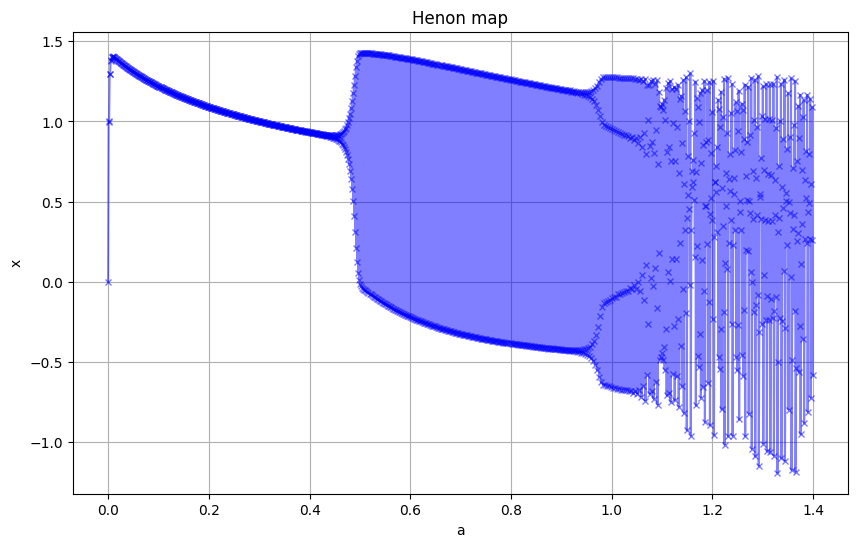

In [2]:
# parameters
b = 0.3
sigma = 0.01
step = 0.001
n_points = 1400

# initialize arrays
x = np.zeros(n_points)
y = np.zeros(n_points)
a = np.zeros(n_points)
gaussian_noise = np.random.normal(0, 1, n_points)

# compute henon map with varying 'a' parameter
for i in range(1, n_points):
    x[i] = 1 - a[i-1] * x[i-1]**2 + b * y[i-1] + sigma * gaussian_noise[i-1] * np.sqrt(step)
    y[i] = x[i-1] + sigma * gaussian_noise[i-1] * np.sqrt(step) 
    a[i] = a[i-1] + step

# plot the trajectory (x vs a) with dots connected by lines
plt.figure(figsize=(10, 6))
plt.plot(a, x, marker='x', markersize=4, linestyle='-', color='blue', alpha=0.5)
plt.title("Henon map")
plt.xlabel("a")
plt.ylabel("x")
plt.grid()
plt.show()

c:\Users\eliot\Desktop\MVA\Time Series\project\.venv\lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


Text(0.5, 1.0, 'Persistence Diagram of Last Sliding Window')

<Figure size 800x600 with 0 Axes>

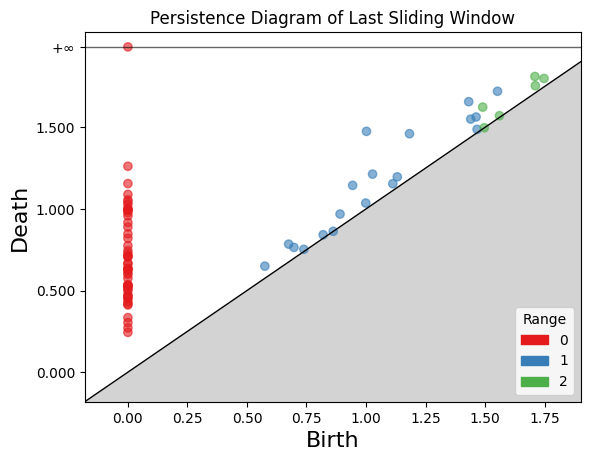

In [3]:
w = 50
b_values = [0.27, 0.28, 0.29, 0.3]

x = np.zeros((n_points, len(b_values)))
y = np.zeros((n_points, len(b_values)))
a = np.zeros((n_points, len(b_values)))
gaussian_noise = np.random.normal(0, 1, (n_points, len(b_values)))

for j, b in enumerate(b_values):
    for i in range(1, n_points):
        x[i, j] = 1 - a[i-1, j] * x[i-1, j]**2 + b * y[i-1, j] + sigma * gaussian_noise[i-1, j] * np.sqrt(step)
        y[i, j] = x[i-1, j] + sigma * gaussian_noise[i-1, j] * np.sqrt(step) 
        a[i, j] = a[i-1, j] + step

# compute the persistence diagrams of this 4D for every sliding window
diagrams = []
for i in range(n_points - w):
    window = x[i:i+w, :]  # shape (w, 4)
    rips = ripser.ripser(window, maxdim=2)
    diagrams.append(rips['dgms'])

# plot the persistence diagram of the last sliding window
plt.figure(figsize=(8, 6))
gd.plot_persistence_diagram(diagrams[-1])
plt.title("Persistence Diagram of Last Sliding Window")

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

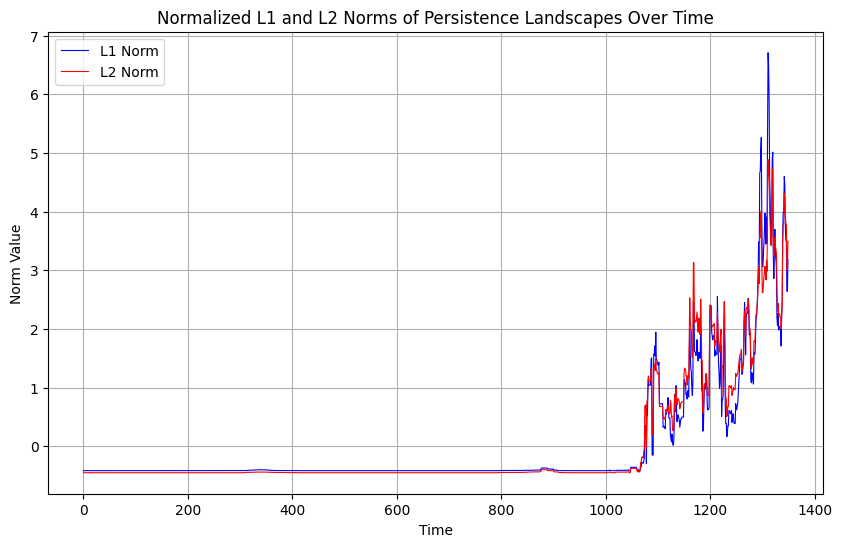

In [4]:
# plot the L^1 and L^2 norms of the persistence landscapes over time on the same plot
import gudhi.representations as grepr

l1_norms = []
l2_norms = []
for diag in diagrams:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms.append(np.sum(np.abs(landscape)))
    l2_norms.append(np.sqrt(np.sum(landscape**2)))

l1_norms = (np.array(l1_norms) - np.mean(l1_norms)) / np.std(l1_norms)
l2_norms = (np.array(l2_norms) - np.mean(l2_norms)) / np.std(l2_norms)

plt.figure(figsize=(10, 6))
plt.plot(l1_norms, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(l2_norms, label='L2 Norm', color='red', linewidth=0.8)
plt.title("Normalized L1 and L2 Norms of Persistence Landscapes Over Time")
plt.xlabel("Time")
plt.ylabel("Norm Value")
plt.legend()
plt.grid()

# White noise with Gamma-distributed inverse variance

In [ ]:
X = []
num_clouds = 100
points_per_cloud = 100
scale_param = 8.0
beta_param = 1.0
M = 100 # number of Monte Carlo simulations

l1_norms_mc = []

for _ in range(M):
    X = []
    scale_param = 8.0
    for i in range(num_clouds):
        if i >= 75:
            scale_param -= 0.25
        variances = np.random.gamma(shape=2.0, scale=scale_param, size=4)
        std_devs = np.sqrt(1 / variances)
        cloud = np.random.normal(loc=0.0, scale=std_devs, size=(points_per_cloud, 4))
        X.append(cloud)
    
    diagrams_mc = []
    for cloud in X:
        rips = ripser.ripser(cloud)
        diagrams_mc.append(rips['dgms'])

    l1_norms_temp = []
    for diag in diagrams_mc:
        pl = grepr.Landscape(num_landscapes=10, resolution=500)
        landscape = pl.fit_transform([diag[1]])[0]
        l1_norms_temp.append(np.sum(np.abs(landscape)))
    l1_norms_mc.append(l1_norms_temp)
    
l1_norms_mc = np.array(l1_norms_mc)
l1_norms = np.mean(l1_norms_mc, axis=0)
l1_norms = (l1_norms - np.mean(l1_norms)) / np.std(l1_norms)


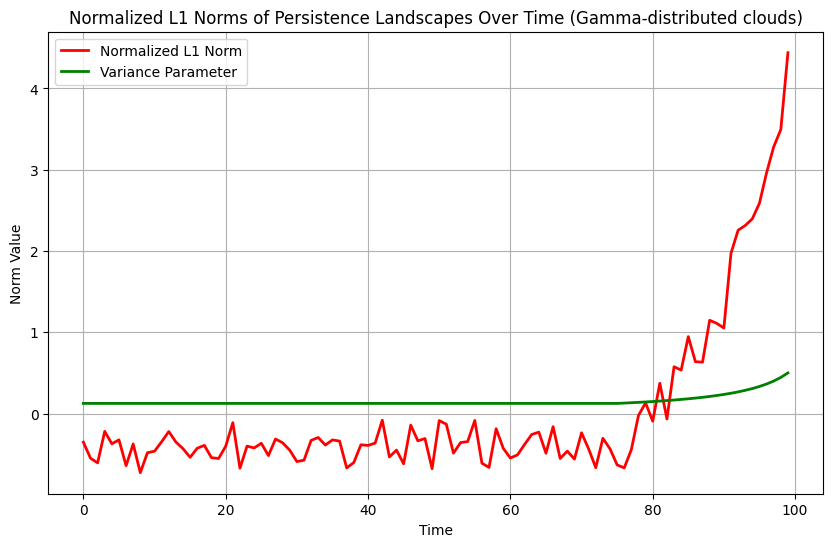

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(l1_norms, label='Normalized L1 Norm', color='red', linewidth=2)
plt.title("Normalized L1 Norms of Persistence Landscapes Over Time (Gamma-distributed clouds)")
plt.xlabel("Time")
plt.ylabel("Norm Value")
plt.legend()
plt.grid()
plt.show()